# Cell Voltage Exploratory Data Analysis 
**Date:** 2026-03-11 | **Session duration:** 124 secs | **Pack:** 84-cell 
## Summary
Pack behavior indicates a critical cell fault requiring immediate attention.
See conclusions for details.

**Imports & Configs**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PATH = '../data/raw/cellvoltages_2026-03-11-15-48-37.csv'
N_CELLS = 84

lsu_colors = ["#4E2A84", "#FDD023","#7F857765","#000000"]  # purple, gold, gray, black
sns.set_theme(style='darkgrid') 
sns.set_palette(sns.color_palette(lsu_colors))
plt.rcParams['figure.figsize'] = (14, 4)

**Dataframe Cleaning**

In [ ]:
df = pd.read_csv(PATH)

DROP_COLS = ([f'Cell Resistance {i}' for i in range(1, N_CELLS + 1)] + 
             [f'Open Cell Voltage {i}' for i in range(1, N_CELLS + 1)]) # Impedance Analysis TBA

CV_COLS = [f'Cell Voltage {i}' for i in range(1, N_CELLS + 1)] # Cell Voltage Columns

df = df.drop(columns=DROP_COLS)
df = df.dropna(axis=1, how='all') #Delete BMS trailing comma
df.columns = df.columns.str.strip()

df['Pack Current'] = df['Pack Current'] * -1 # Make positive when Charging (human intuitive)

df['Time'] = pd.to_datetime( 
    df['Time'].str.replace(r'\s+[A-Z]{2,4}\s+', ' ', regex=True),
    format='%a %b %d %H:%M:%S %Y')

df['elapsed_s'] = (df['Time'] - df['Time'].iloc[0]).dt.total_seconds()

SESSION_ID = "002"
df['session_id'] = SESSION_ID

print(df.isnull().sum().sum(), 'total missing values')

0 total missing values


**Pack Data Overview**

In [3]:
print(f'Duration: {df["elapsed_s"].max():.1f} sec')
print(df.shape)
df.head()

Duration: 124.0 sec
(191, 101)


,Time,State of Charge,Pack Voltage,Pack Current,Pack CCL,Pack DCL,Highest Cell ID,Highest Cell Volt,Lowest Cell ID,Lowest Cell Volt,...,Cell Voltage 77,Cell Voltage 78,Cell Voltage 79,Cell Voltage 80,Cell Voltage 81,Cell Voltage 82,Cell Voltage 83,Cell Voltage 84,elapsed_s,session_id
0,2026-03-11 15:48:41,50.0,303.0,-0.0,6,198,82,3.6098,9,3.5939,...,3.6090,3.6096,3.6080,3.6084,3.6082,3.6098,3.6084,3.6073,0.0,002
1,2026-03-11 15:48:42,50.0,303.0,0.2,6,198,23,3.6097,9,3.5940,...,3.6090,3.6096,3.6081,3.6085,3.6082,3.6097,3.6085,3.6071,1.0,002
2,2026-03-11 15:48:42,50.0,303.0,-0.0,6,198,39,3.6097,9,3.5940,...,3.6091,3.6096,3.6082,3.6084,3.6083,3.6097,3.6085,3.6073,1.0,002
3,2026-03-11 15:48:43,50.0,303.0,-0.0,6,198,39,3.6098,9,3.5939,...,3.6089,3.6096,3.6081,3.6085,3.6083,3.6098,3.6085,3.6073,2.0,002
4,2026-03-11 15:48:44,50.0,303.0,0.2,6,198,82,3.6097,9,3.5941,...,3.6089,3.6096,3.6082,3.6084,3.6083,3.6097,3.6085,3.6071,3.0,002


**Pack Current & Voltage Over Time**

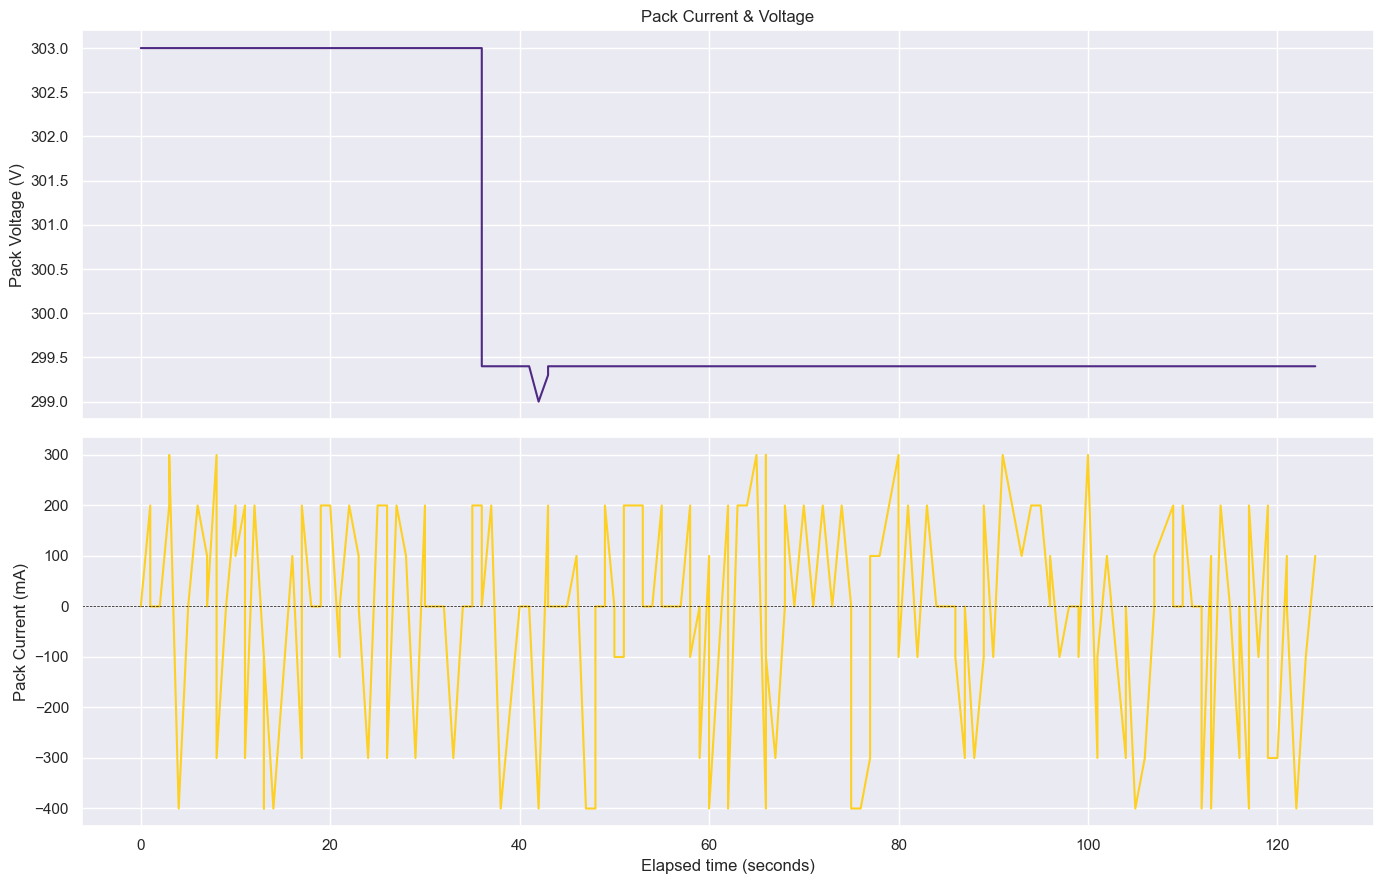

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df['elapsed_s'], df['Pack Voltage'])
axes[0].set_ylabel('Pack Voltage (V)')
axes[0].set_title('Pack Current & Voltage')

axes[1].plot(df['elapsed_s'], df['Pack Current'] * 1000, color = '#FDD023')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Pack Current (mA)')
axes[1].set_xlabel('Elapsed time (seconds)')

plt.tight_layout()
plt.show()

**Voltage Spread Over Time**

C:\Users\randl\AppData\Local\Temp\ipykernel_29412\3191995062.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']


Text(0.5, 0, 'Elapsed time (sec)')

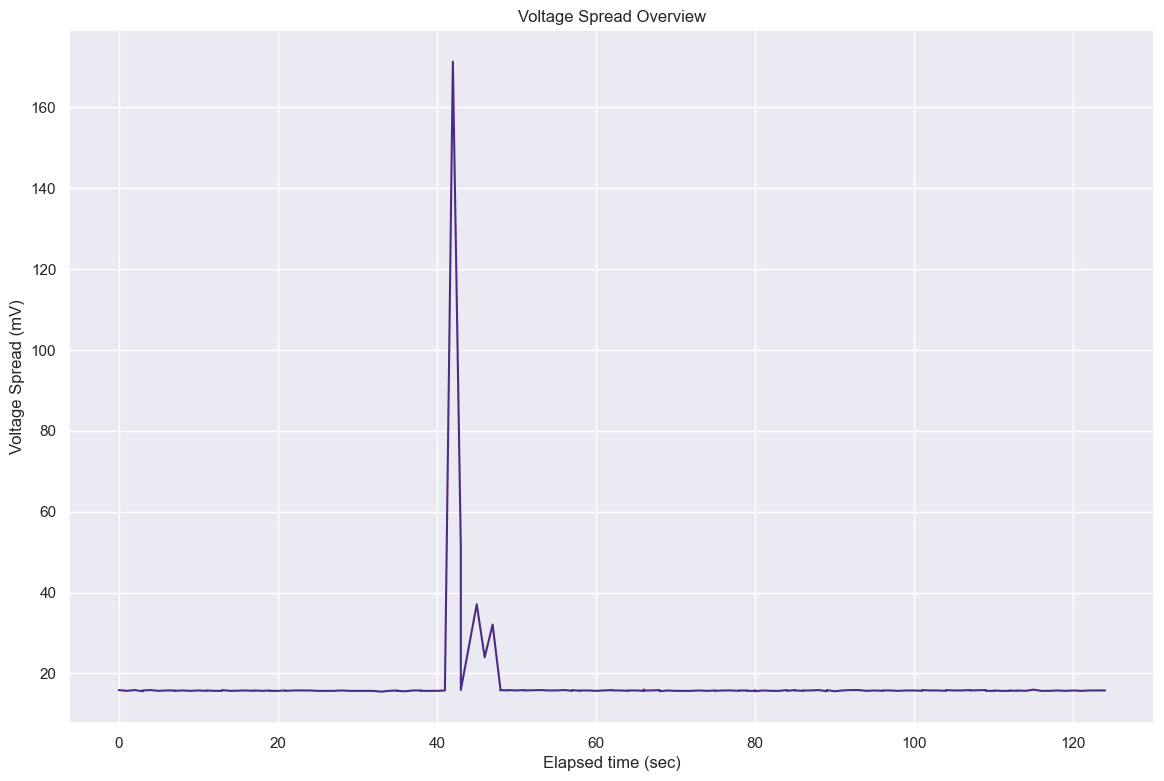

In [5]:
df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']

fig,ax = plt.subplots(1, 1, figsize=(14, 9))
ax.plot(df['elapsed_s'], df['Voltage Spread'] * 1000)
ax.set_title('Voltage Spread Overview')
ax.set_ylabel('Voltage Spread (mV)')
ax.set_xlabel('Elapsed time (sec)')


**Mean Voltage And Mean Rank Per Cell**

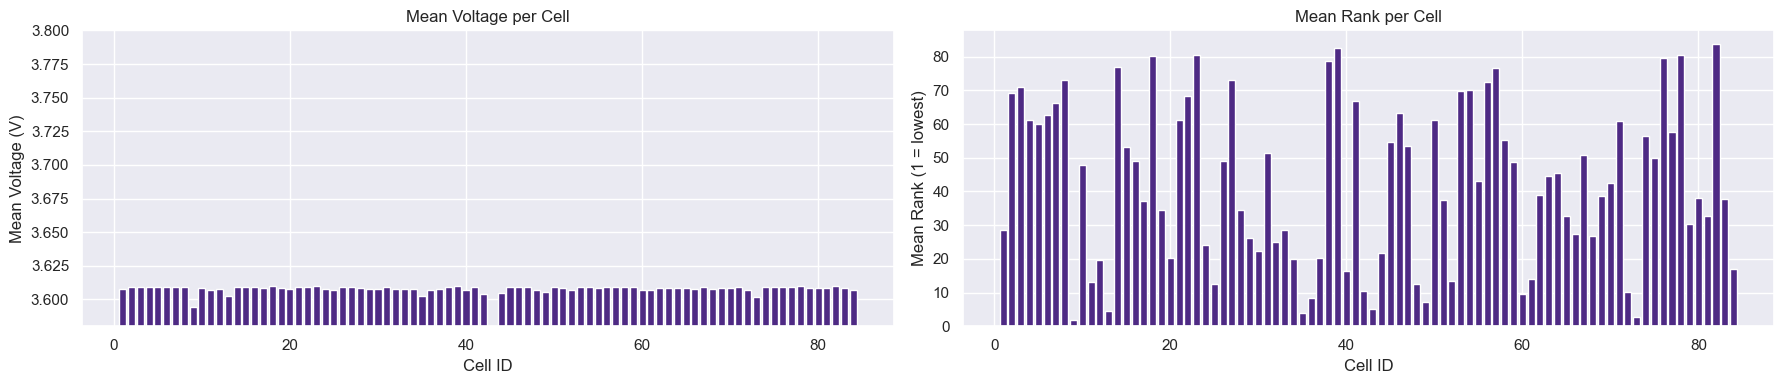

In [6]:
CV_COLS_NUMS = range(1, N_CELLS + 1)
cell_mean_voltage = df[CV_COLS].mean()
cell_mean_rank = df[CV_COLS].rank(axis=1).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))

ax1.bar(CV_COLS_NUMS, cell_mean_voltage)
ax1.set_ylim(3.58, 3.8)
ax1.set_title('Mean Voltage per Cell')
ax1.set_xlabel('Cell ID')
ax1.set_ylabel('Mean Voltage (V)')

ax2.bar(CV_COLS_NUMS, cell_mean_rank)
ax2.set_title('Mean Rank per Cell')
ax2.set_xlabel('Cell ID')
ax2.set_ylabel('Mean Rank (1 = lowest)')

plt.tight_layout()
plt.show()

**Mean Cell Rank Distribution**

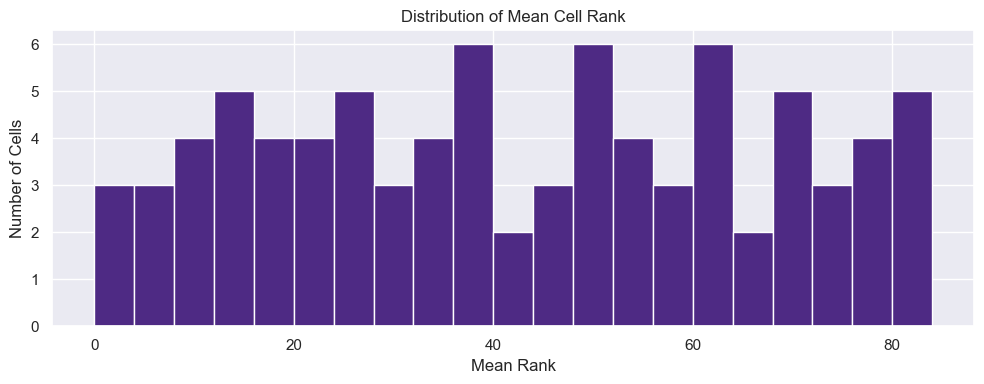

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cell_mean_rank, bins=range(0, 85, 4))
ax.set_title('Distribution of Mean Cell Rank')
ax.set_xlabel('Mean Rank')
ax.set_ylabel('Number of Cells')

plt.tight_layout()
plt.show()

**Cell Voltage By Z-Score (Std Deviations From 0)**

Cell Voltage 43   -9.055777
Cell Voltage 9     0.059885
Cell Voltage 73    0.087744
Cell Voltage 35    0.090584
Cell Voltage 13    0.090968
dtype: float64
Cell Voltage 82    0.115310
Cell Voltage 39    0.115034
Cell Voltage 78    0.114756
dtype: float64


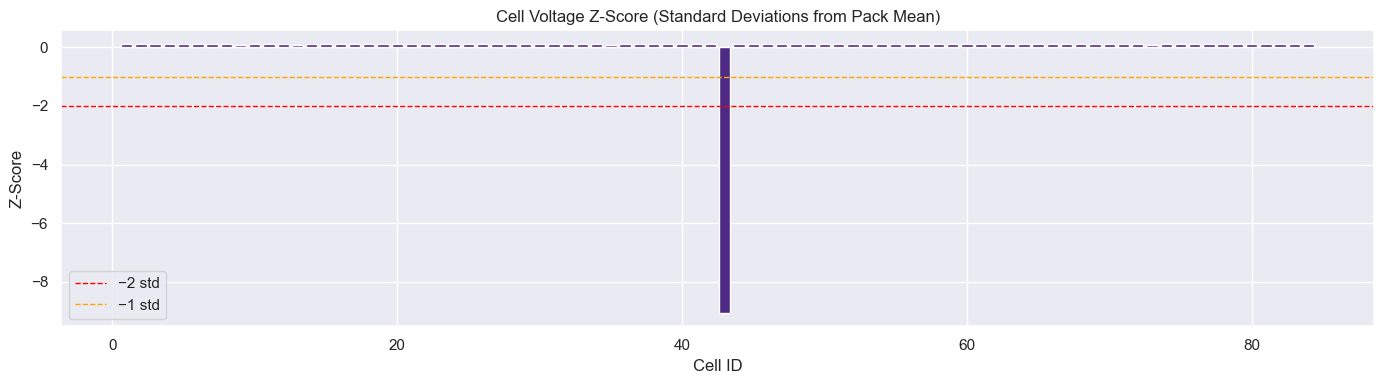

In [8]:
pack_mean_voltage = cell_mean_voltage.mean()
pack_std_voltage = cell_mean_voltage.std()

z_scores = (cell_mean_voltage - pack_mean_voltage) / pack_std_voltage

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(1, N_CELLS + 1), z_scores)
ax.axhline(-2, color='red', linestyle='--', linewidth=1, label='−2 std')
ax.axhline(-1, color='orange', linestyle='--', linewidth=1, label='−1 std')
ax.set_title('Cell Voltage Z-Score (Standard Deviations from Pack Mean)')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Z-Score')
ax.legend()

plt.tight_layout()
print(z_scores.nsmallest(5))
print(z_scores.nlargest(3))
plt.show()


**Voltage Of Special Cells Vs Pack Mean Voltage**

Mean Voltage of Weakest Cells (V)
Cell Voltage 43    1.001015
Cell Voltage 9     3.593982
Cell Voltage 73    3.601907
Cell Voltage 35    3.602715
Cell Voltage 13    3.602824
dtype: float64
Mean Rank of Weakest Cells (1-84)
Cell Voltage 9     1.774869
Cell Voltage 73    2.774869
Cell Voltage 35    3.926702
Cell Voltage 13    4.623037
Cell Voltage 43    5.253927
dtype: float64


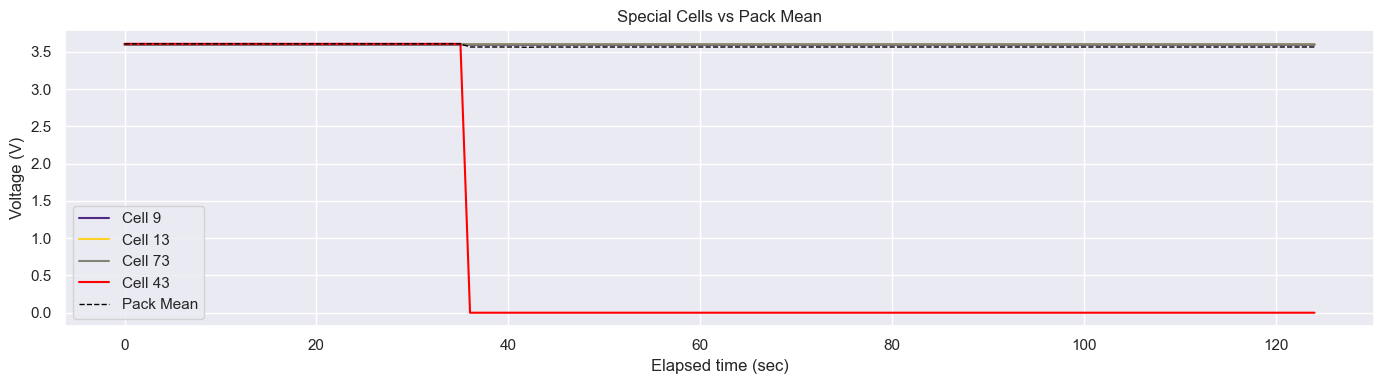

In [9]:
print("Mean Voltage of Weakest Cells (V)")
print(cell_mean_voltage.nsmallest(5))
print("Mean Rank of Weakest Cells (1-84)")
print(cell_mean_rank.nsmallest(5))

pack_mean = df[CV_COLS].mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['elapsed_s'], df['Cell Voltage 9'],  label='Cell 9')
ax.plot(df['elapsed_s'], df['Cell Voltage 13'], label='Cell 13')
ax.plot(df['elapsed_s'], df['Cell Voltage 73'], label='Cell 73')
ax.plot(df['elapsed_s'], df['Cell Voltage 43'], label='Cell 43', color='red') # anomalous above mean voltage
ax.plot(df['elapsed_s'], pack_mean, label='Pack Mean', color='black', linestyle='--', linewidth=1)
ax.set_title('Special Cells vs Pack Mean')
ax.set_xlabel('Elapsed time (sec)')
ax.set_ylabel('Voltage (V)')
ax.legend()

plt.tight_layout()
plt.show()

## Conclusion
### **Pack Health Overview**
The pack voltage drops sharply at t ≈ 36s from ~303V to ~299.5V before stabilizing, likely reflecting a BMS response to the Cell 43 fault. Pack current is erratic and oscillating throughout the session.
### **Cell 43**
Cell 43 voltage collapses to near 0V at t ≈ 36s and remains that value for the duration of the session, registering ~-9.1 standard deviations from pack mean. Notably, cell 43 was anomalously high at +6.9 standard deviations in session 1. This reversal from overperformance to near-zero voltage across two sessions is consistent with accelerated degradation, possibly caused by overcharging. Cell 43 should be escalated to senior team members for physical inspection immediately.

### **Notes & Next Steps**
**Note:** Cell 43's behavior across both sessions — anomalously high voltage in session 1 followed by near-zero voltage in session 2 — is sufficient to draw firm conclusions without further sessions.

**Next steps:** Escalate cell 43 for physical inspection before further charging. Cells 9, 13, and 73 could not be meaningfully evaluated this session due to cell 43 dominating pack statistics; re-examine in a future session once pack behavior normalizes.